# MobileNetV2 Training Notebook

This notebook trains a MobileNetV2 classifier on the RealWaste dataset using the preprocessing pipeline in `src/preprocess.py`.

It keeps everything inside the notebook: data loading, training, evaluation, and plots.

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from tensorflow.keras import layers, Model, optimizers, losses
from tensorflow.keras.applications import MobileNetV2

possible_roots = [Path.cwd(), Path.cwd().parent]
for root in possible_roots:
    if (root / 'src').exists():
        REPO_ROOT = root
        break
else:
    REPO_ROOT = Path.cwd()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.preprocess import prepare_datasets

print('Repo root:', REPO_ROOT)
print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))
print('CPUs:', tf.config.list_physical_devices('CPU'))

Repo root: /Users/luannguyen/PersonalProjects/garbage-material-classification
TensorFlow version: 2.20.0
GPUs: []
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [9]:
# Config
DATA_DIR = str(REPO_ROOT / 'data' / 'RealWaste')
IMG_SIZE = 224
BATCH_SIZE = 8
TRAIN_EPOCHS = 50
FINE_TUNE_EPOCHS = 50
LR = 1e-3
FT_LR_SCALE = 0.1
DROPOUT = 0.2
UNFREEZE_LAYERS = 50

data = prepare_datasets(
    data_dir=DATA_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    model_type='mobilenetv2',
)

train_ds = data['train_ds']
val_ds = data['val_ds']
test_ds = data['test_ds']
class_weights = data['class_weights']
class_names = data['class_names']
num_classes = len(class_names)

print('Classes:', class_names)
print('Num classes:', num_classes)
print('Data dir:', DATA_DIR)

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Class counts: {'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}
Unreadable files: 0
Train: 3800 | Val: 476 | Test: 476
Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Num classes: 9
Data dir: /Users/luannguyen/PersonalProjects/garbage-material-classification/data/RealWaste


In [10]:
# Build the MobileNetV2 transfer-learning model
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling='avg',
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# Phase 1: feature extraction
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TRAIN_EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stopping]  # add this
)

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 37s 68ms/step - accuracy: 0.4772 - loss: 1.4922 - val_accuracy: 0.6387 - val_loss: 0.9771
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 38s 75ms/step - accuracy: 0.7230 - loss: 0.7279 - val_accuracy: 0.7080 - val_loss: 0.8859
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 40s 79ms/step - accuracy: 0.7618 - loss: 0.6386 - val_accuracy: 0.6807 - val_loss: 0.8945
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 42s 82ms/step - accuracy: 0.7708 - loss: 0.5538 - val_accuracy: 0.7143 - val_loss: 0.8206
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 41s 80ms/step - accuracy: 0.8112 - loss: 0.5068 - val_accuracy: 0.7206 - val_loss: 0.8031
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - accuracy: 0.8249 - loss: 0.4691 - val_accuracy: 0.7416 - val_loss: 0.7571
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 46s 90ms/step - accuracy: 0.8139 - loss: 0.4643 - val_accuracy: 0.7332 - val_loss: 0.8029
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 45s 87ms/step - accuracy: 0.8385 - loss: 0.4273 - 

In [12]:
# Phase 2: fine-tuning
history2 = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

if FINE_TUNE_EPOCHS > 0 and UNFREEZE_LAYERS > 0:
    base_model.trainable = True
    if UNFREEZE_LAYERS < len(base_model.layers):
        for layer in base_model.layers[:-UNFREEZE_LAYERS]:
            layer.trainable = False
        for layer in base_model.layers[-UNFREEZE_LAYERS:]:
            layer.trainable = True

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR * FT_LR_SCALE),
        loss=losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    early_stopping_ft = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history2_run = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        class_weight=class_weights,
        callbacks=[early_stopping_ft] 
    )

    history2 = history2_run.history
else:
    print('Fine-tuning skipped because FINE_TUNE_EPOCHS is 0.')

Epoch 1/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 73s 135ms/step - accuracy: 0.6554 - loss: 0.9867 - val_accuracy: 0.7059 - val_loss: 1.4058
Epoch 2/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 71s 142ms/step - accuracy: 0.7709 - loss: 0.5897 - val_accuracy: 0.7437 - val_loss: 1.0690
Epoch 3/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - accuracy: 0.8223 - loss: 0.4567 - val_accuracy: 0.7794 - val_loss: 0.8257
Epoch 4/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 72s 142ms/step - accuracy: 0.8537 - loss: 0.3678 - val_accuracy: 0.7395 - val_loss: 1.1310
Epoch 5/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 67s 135ms/step - accuracy: 0.8947 - loss: 0.2935 - val_accuracy: 0.7122 - val_loss: 1.2159
Epoch 6/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.8970 - loss: 0.2658 - val_accuracy: 0.7836 - val_loss: 0.9715
Epoch 7/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 70s 140ms/step - accuracy: 0.9144 - loss: 0.2081 - val_accuracy: 0.7584 - val_loss: 1.0649
Epoch 8/50
475/475 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - accuracy: 0.9433 - loss: 0

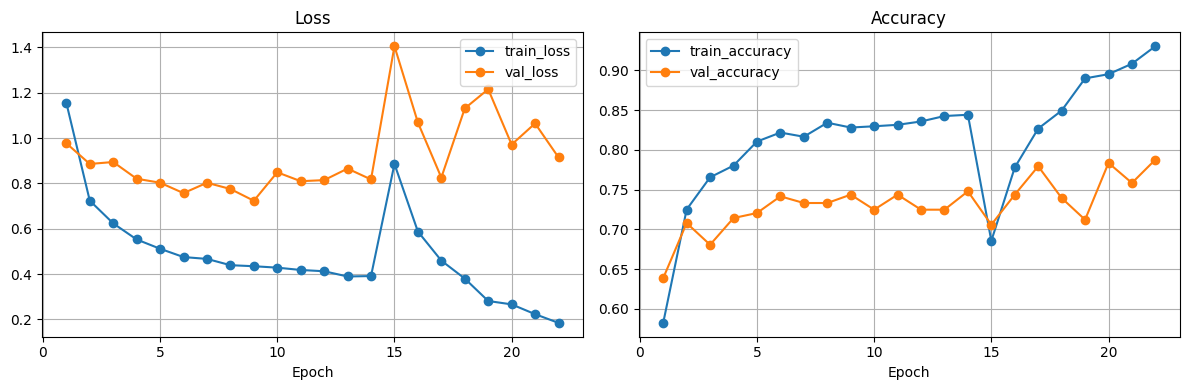

In [13]:
# Plot training curves inline
merged_history = {
    'loss': history1.history.get('loss', []) + history2.get('loss', []),
    'accuracy': history1.history.get('accuracy', []) + history2.get('accuracy', []),
    'val_loss': history1.history.get('val_loss', []) + history2.get('val_loss', []),
    'val_accuracy': history1.history.get('val_accuracy', []) + history2.get('val_accuracy', []),
}

epochs = list(range(1, len(merged_history['loss']) + 1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, merged_history['loss'], marker='o', label='train_loss')
axes[0].plot(epochs, merged_history['val_loss'], marker='o', label='val_loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, merged_history['accuracy'], marker='o', label='train_accuracy')
axes[1].plot(epochs, merged_history['val_accuracy'], marker='o', label='val_accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

if len(epochs) == 1:
    for ax in axes:
        ax.set_xlim(0.5, 1.5)

plt.tight_layout()
plt.show()

In [14]:
# Final evaluation

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)
print('Macro precision:', precision_macro)
print('Macro recall:', recall_macro)
print('Macro F1:', f1_macro)
print('Weighted precision:', precision_weighted)
print('Weighted recall:', recall_weighted)
print('Weighted F1:', f1_weighted)
print('\nClassification report:\n')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test loss: 0.7238358855247498
Test accuracy: 0.8214285969734192
Macro precision: 0.8266791738222659
Macro recall: 0.8345099142162111
Macro F1: 0.8249026831653415
Weighted precision: 0.8338996833769566
Weighted recall: 0.8214285714285714
Weighted F1: 0.8213546012147637

Classification report:

                     precision    recall  f1-score   support

          Cardboard       0.80      0.89      0.85        46
      Food Organics       0.84      0.78      0.81        41
              Glass       0.83      0.93      0.88        42
              Metal       0.88      0.84      0.86        79
Miscellaneous Trash       0.60      0.76      0.67        50
              Paper       0.83      0.88      0.85        50
            Plastic       0.91      0.68      0.78        92
      Textile Trash       0.92      0.75      0.83        32
         Vegetation       0.81      1.00      0.90        44

           accuracy                           0.82       476
          macro avg       0.83   

2026-05-02 00:41:59.349457: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


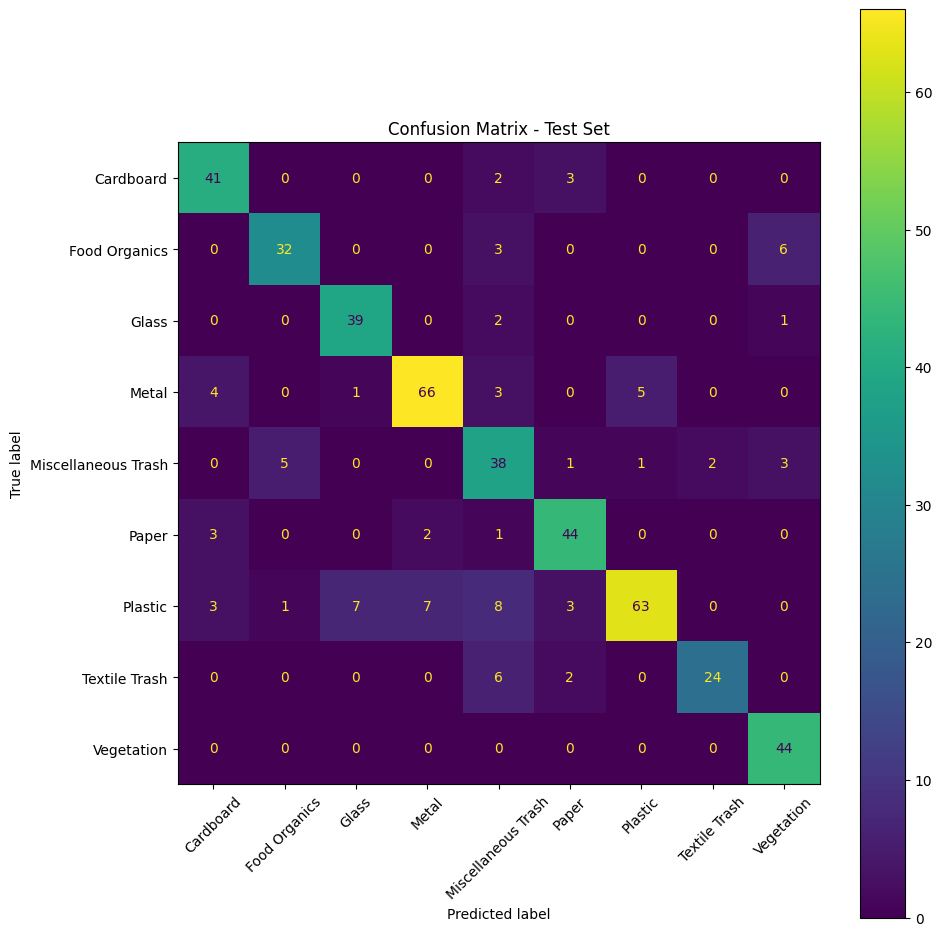

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

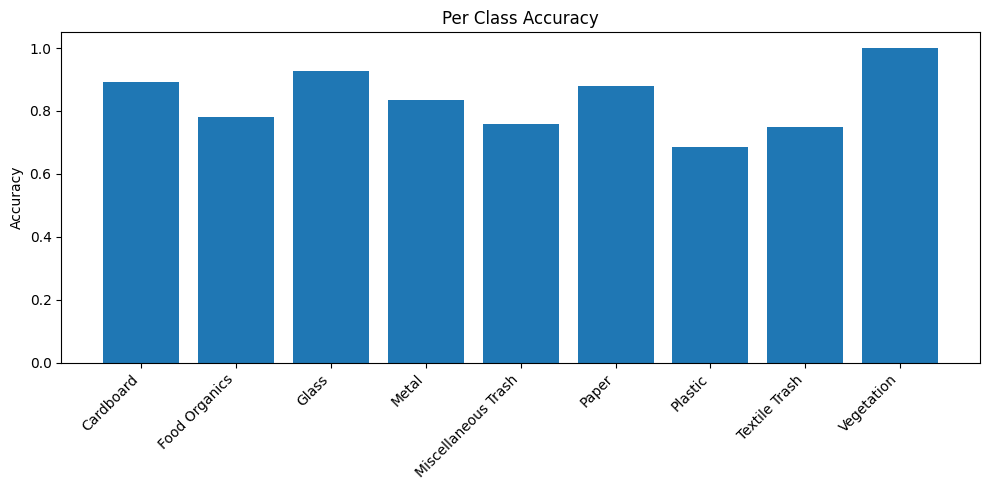

In [16]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(10, 5))
plt.bar(class_names, per_class_acc)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Per Class Accuracy')
plt.tight_layout()
plt.show()

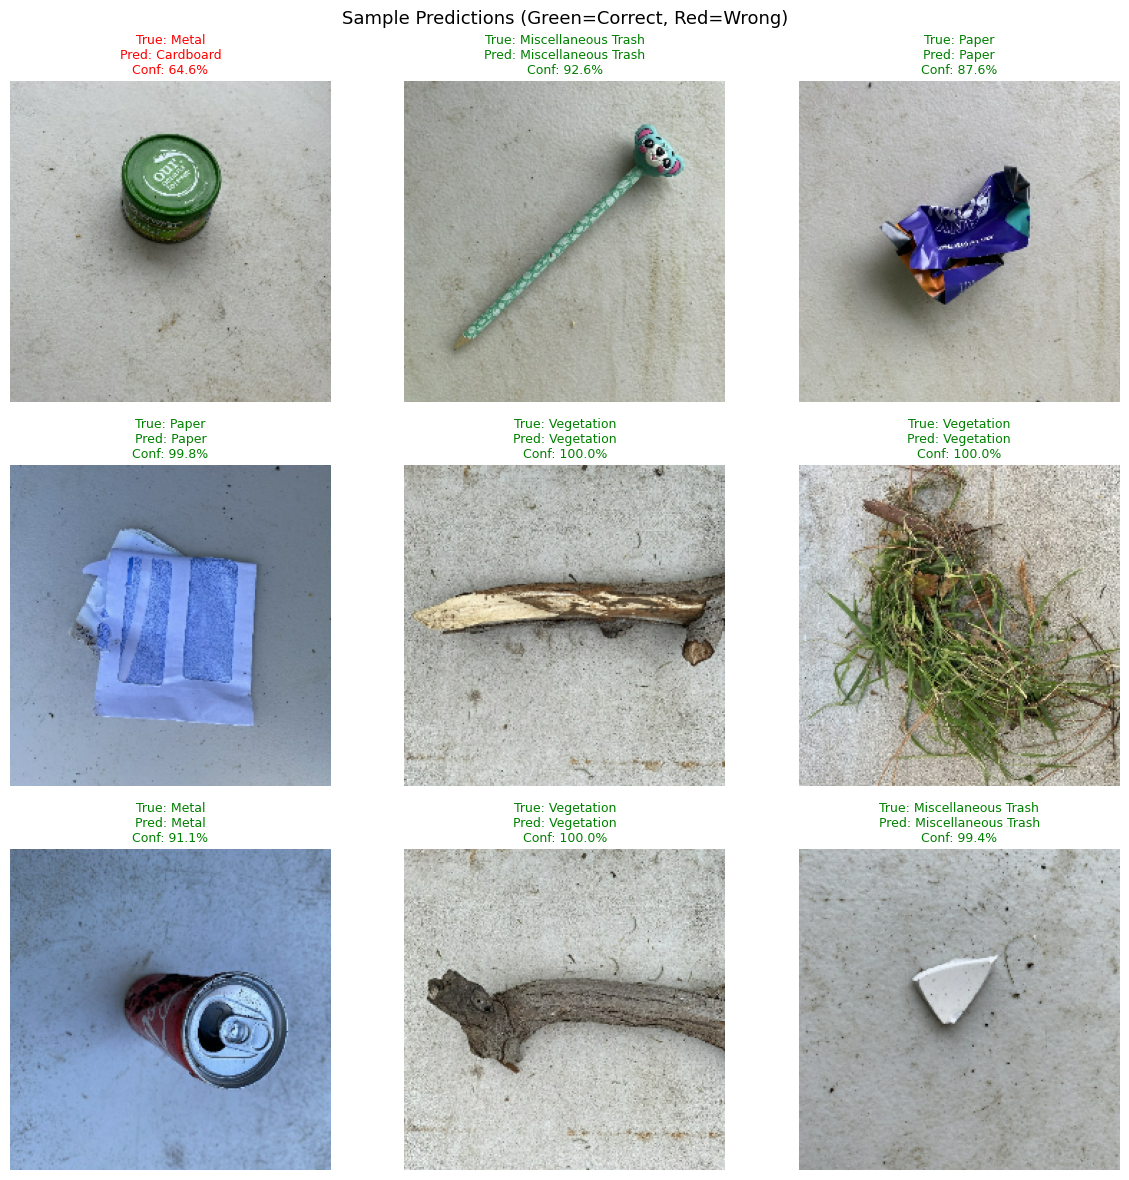

In [18]:
import math

def visualize_predictions(model, test_ds, class_names, num_examples=9):
    images_shown = []
    labels_shown = []
    
    for images, labels in test_ds:
        images_shown.append(images.numpy())
        labels_shown.append(labels.numpy())
        if sum(len(x) for x in images_shown) >= num_examples:
            break
    
    images_shown = np.concatenate(images_shown)[:num_examples]
    labels_shown = np.concatenate(labels_shown)[:num_examples]
    
    probs = model.predict(tf.constant(images_shown), verbose=0)  # softmax probabilities
    preds = np.argmax(probs, axis=1)
    confidences = np.max(probs, axis=1)  # ← highest probability = confidence
    
    cols = 3
    rows = math.ceil(num_examples / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.ravel()
    
    for i in range(num_examples):
        img = images_shown[i].copy()
        img = (img - img.min()) / (img.max() - img.min())
        
        axes[i].imshow(img)
        
        true_label = class_names[labels_shown[i]]
        pred_label = class_names[preds[i]]
        confidence = confidences[i] * 100  # convert to percentage
        correct = labels_shown[i] == preds[i]
        
        color = 'green' if correct else 'red'
        title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%"  # ← added
        axes[i].set_title(title, color=color, fontsize=9)
        axes[i].axis('off')
    
    for i in range(num_examples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_ds, class_names, num_examples=9)